In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('dataset/data_science_job.csv')
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,NaN,NaN,42.0,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,NaN,NaN,52.0,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,50-99,Pvt Ltd,44.0,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,0.0,500-999,Pvt Ltd,97.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [4]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [5]:
df.isnull().mean()*100  # Show mean of missing data

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [6]:
df.shape

(19158, 13)

In [7]:
cols=[var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols  # it show 0.05 precent to down nan value

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [9]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
17852,0.624,no_enrollment,Graduate,9.0,43.0
9640,0.848,Full time course,High School,6.0,67.0
13041,0.910,no_enrollment,Graduate,20.0,44.0
8473,0.624,no_enrollment,Graduate,10.0,149.0
2768,0.624,Full time course,Graduate,2.0,114.0


# drop then this ammount data safe

In [10]:
len(df[cols].dropna()) /len(df)

0.8968577095730244

In [11]:
new_df=df[cols].dropna()
df.shape,new_df.shape

((19158, 13), (17182, 5))

In [12]:
import seaborn as sns

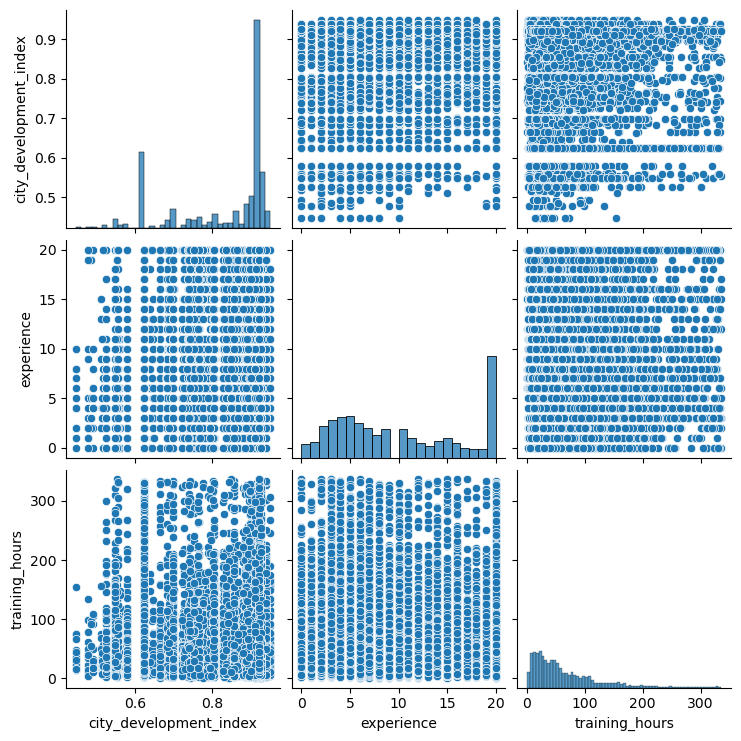

In [13]:
sns.pairplot(new_df)

# Analyze all drop columns

In [16]:
import matplotlib.pyplot as plt

<Axes: >

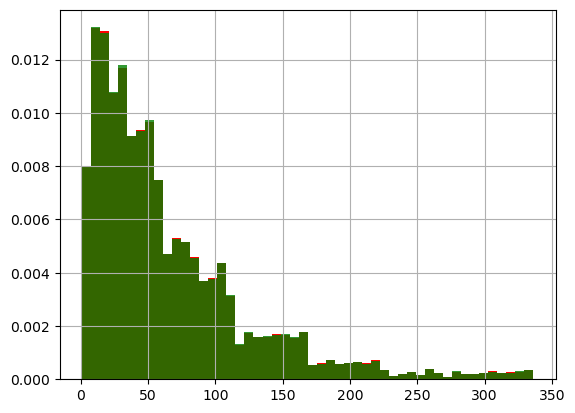

In [17]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original data
df['training_hours'].hist(bins=50,ax=ax,density=True,color='red')

# data after cca 
new_df['training_hours'].hist(bins=50,ax=ax,density=True,color='green',alpha=0.8)

 # Pdf

<Axes: ylabel='Density'>

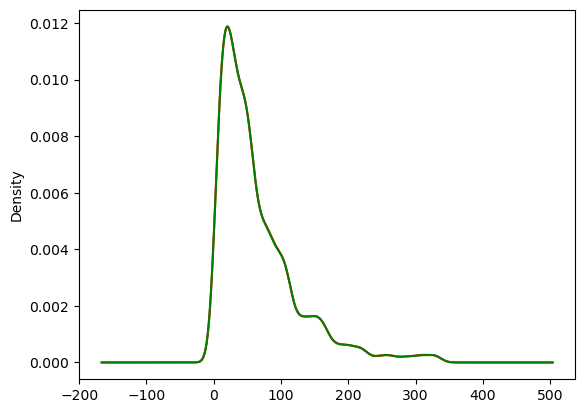

In [18]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca
new_df['training_hours'].plot.density(color='green')

<Axes: >

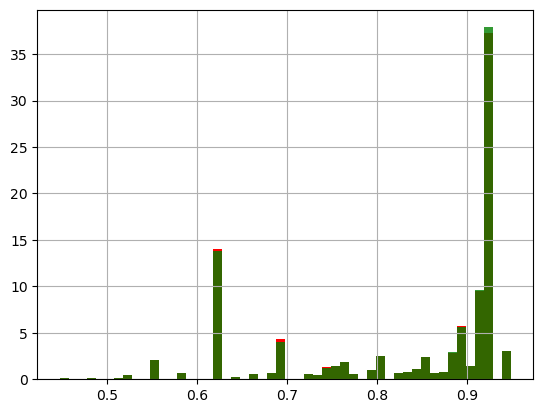

In [19]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original data
df['city_development_index'].hist(bins=50,ax=ax,density=True,color='red')

# data after cca 
new_df['city_development_index'].hist(bins=50,ax=ax,density=True,color='green',alpha=0.8)

<Axes: ylabel='Density'>

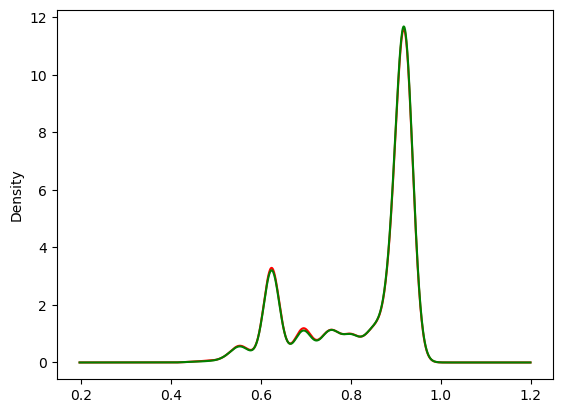

In [20]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original data
df['city_development_index'].plot.density(color='red')

# data after cca
new_df['city_development_index'].plot.density(color='green')

<Axes: >

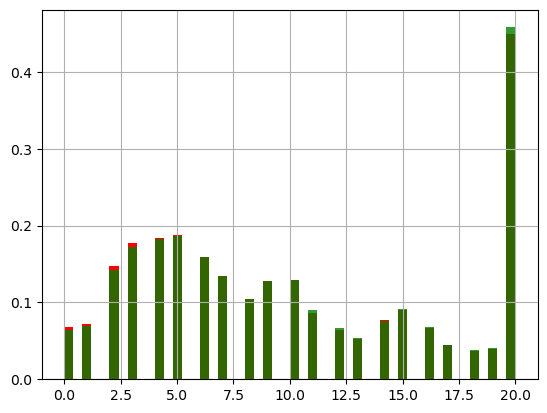

In [22]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original data
df['experience'].hist(bins=50,ax=ax,density=True,color='red')

# data after cca 
new_df['experience'].hist(bins=50,ax=ax,density=True,color='green',alpha=0.8)

<Axes: ylabel='Density'>

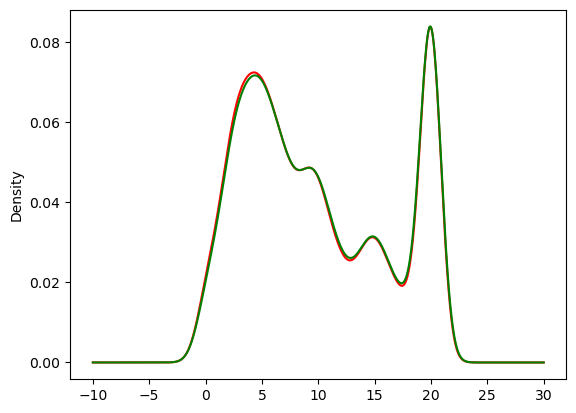

In [23]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original data
df['experience'].plot.density(color='red')

# data after cca
new_df['experience'].plot.density(color='green')

# About Categorical data

In [27]:
df[cols].head()

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
3,0.789,NaN,Graduate,0.0,52.0
4,0.767,no_enrollment,Masters,20.0,8.0


In [28]:
df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

In [29]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [26]:
temp=pd.concat([
    # percentage of observation per category ,original data
    df['enrolled_university'].value_counts() / len(df),

    # percentage of observation per category cca
    new_df['enrolled_university'].value_counts()/len(new_df)
],axis=1)

# add column name
temp.columns=['original','cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [30]:
temp1=pd.concat([
    # percentage of observation per category ,original data
    df['education_level'].value_counts() / len(df),

    # percentage of observation per category cca
    new_df['education_level'].value_counts()/len(new_df)
],axis=1)

# add column name
temp1.columns=['original','cca']
temp1

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
